# **⭐ Classification Model to Identify Multiple Disease**

In [67]:
# import library


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#import data

url = "https://github.com/ybifoundation/Dataset/raw/main/MultipleDiseasePrediction.csv"
disease = pd.read_csv(url)


In [68]:
# 2. view data

print("Dataset Shape:", disease.shape)
disease.head()

Dataset Shape: (4920, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [69]:
# 3. info of data
print("\nInfo:\n")
disease.info()

print("\nMissing Values:\n")
print(disease.isna().sum().sum())

print("\nUnique Classes:")
print(disease['prognosis'].nunique())


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB

Missing Values:

0

Unique Classes:
41


In [70]:

# 4. Define Features & Target

X = disease.drop('prognosis', axis=1)
y = disease['prognosis']

print("X Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (4920, 132)
y Shape: (4920,)


In [71]:

# 5. Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2559
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (3690, 132)
Testing Shape: (1230, 132)


In [72]:
# 6. Model Training


model = RandomForestClassifier(random_state=2559)
model.fit(X_train, y_train)



RandomForestClassifier(random_state=2559)

In [73]:
# 7. Prediction


y_pred = model.predict(X_test)


In [74]:
# 8. Model Evaluation

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        29
                                   AIDS       1.00      1.00      1.00        29
                                   Acne       1.00      1.00      1.00        27
                    Alcoholic hepatitis       1.00      1.00      1.00        30
                                Allergy       1.00      1.00      1.00        32
                              Arthritis       1.00      1.00      1.00        35
                       Bronchial Asthma       1.00      1.00      1.00        36
                   Cervical spondylosis       1.00      1.00      1.00        31
                            Chicken pox       1.00      1.00      1.00        30
                    Chronic cholestasis       1.00      1.00      1.00        28
                            Common Cold       1.00      1.00      1.0

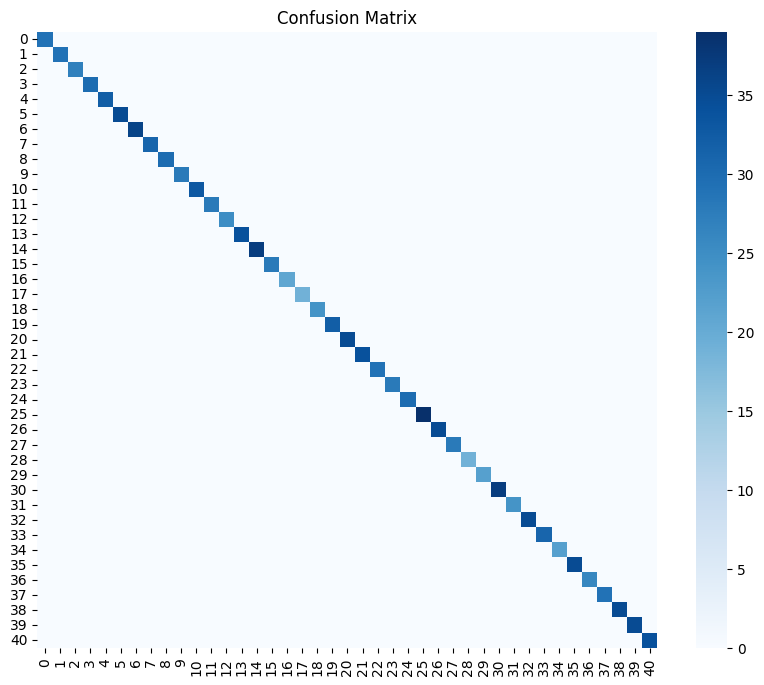

In [75]:
# 9. Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [76]:
# 10. Future Prediction


# Random sample prediction
X_new = X.sample(1)
prediction = model.predict(X_new)

print("Predicted Disease:", prediction[0])


Predicted Disease: Tuberculosis
